# Figuras y cuadros del capítulo de Resultados

Todas las figuras salen de los CSV de `results/`, que a su vez vienen de las corridas en Kaggle o de los notebooks locales. Cada figura se guarda en `results/figuras/` a 200 ppp para insertarla en el documento.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
R = ROOT / "results"
FIG = R / "figuras"
FIG.mkdir(exist_ok=True)

AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, TINTA_2, REJILLA = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10, "font.family": "serif",
    "axes.edgecolor": TINTA_2, "axes.labelcolor": TINTA, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": REJILLA,
    "grid.linewidth": 0.6, "axes.axisbelow": True, "legend.frameon": False,
})

def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(FIG / f"{nombre}.png", bbox_inches="tight", facecolor="white")

## Primer objetivo: selección del modelo

f1_onset         f1_note             ner          \
                           mean     std    mean     std    mean     std   
model                                                                     
Kong et al. (2021)       0.9589  0.0282  0.8374  0.0487  0.0801  0.0540   
hFT-Transformer (2023)   0.9668  0.0244  0.8930  0.0435  0.0636  0.0452   
Basic Pitch (2022)       0.6475  0.0821  0.1946  0.0671  0.6337  0.1148   

                       latency_norm          
                               mean     std  
model                                        
Kong et al. (2021)           0.0969  0.0027  
hFT-Transformer (2023)       0.0791  0.0083  
Basic Pitch (2022)           0.0302  0.0142

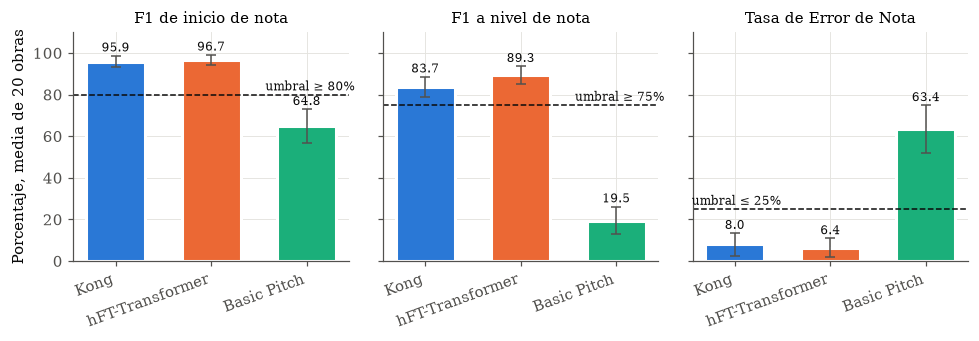

In [2]:
b = pd.read_csv(R / "oe1_benchmark_por_obra.csv")
orden = ["Kong et al. (2021)", "hFT-Transformer (2023)", "Basic Pitch (2022)"]
nombres = {"Kong et al. (2021)": "Kong", "hFT-Transformer (2023)": "hFT-Transformer", "Basic Pitch (2022)": "Basic Pitch"}
colores = [AZUL, NARANJA, AQUA]
metricas = [("f1_onset", "F1 de inicio de nota", 0.80, "≥"), ("f1_note", "F1 a nivel de nota", 0.75, "≥"), ("ner", "Tasa de Error de Nota", 0.25, "≤")]

fig, ejes = plt.subplots(1, 3, figsize=(9, 3.2), sharey=True)
for ax, (col, titulo, umbral, signo) in zip(ejes, metricas):
    g = b.groupby("model")[col].agg(["mean", "std"]).reindex(orden) * 100
    x = range(len(orden))
    ax.bar(x, g["mean"], yerr=g["std"], color=colores, width=0.62, edgecolor="white", linewidth=2, capsize=3, error_kw={"elinewidth": 1, "ecolor": TINTA_2})
    ax.axhline(umbral * 100, color=TINTA, linestyle="--", linewidth=1)
    izquierda = col == "ner"
    ax.text(-0.45 if izquierda else len(orden) - 0.5, umbral * 100 + 2, f"umbral {signo} {umbral:.0%}",
            ha="left" if izquierda else "right", fontsize=8, color=TINTA)
    for i, v in enumerate(g["mean"]):
        ax.text(i, v + g["std"].iloc[i] + 2, f"{v:.1f}", ha="center", fontsize=8, color=TINTA)
    ax.set_xticks(list(x), [nombres[m] for m in orden], rotation=20, ha="right")
    ax.set_title(titulo, fontsize=10)
    ax.set_ylim(0, 110)
ejes[0].set_ylabel("Porcentaje, media de 20 obras")
guardar(fig, "oe1_benchmark")
b.groupby("model")[["f1_onset", "f1_note", "ner", "latency_norm"]].agg(["mean", "std"]).reindex(orden).round(4)

## Segundo objetivo: robustez y ajuste fino

variant,ajustado,original,original_norm
condition,,,
limpio,82.81,83.81,83.77
mp3,82.30,82.21,82.23
ruido,76.81,75.24,75.09
reverb,68.66,62.58,62.57
celular,59.58,44.14,43.92
bajo,82.81,54.40,83.77


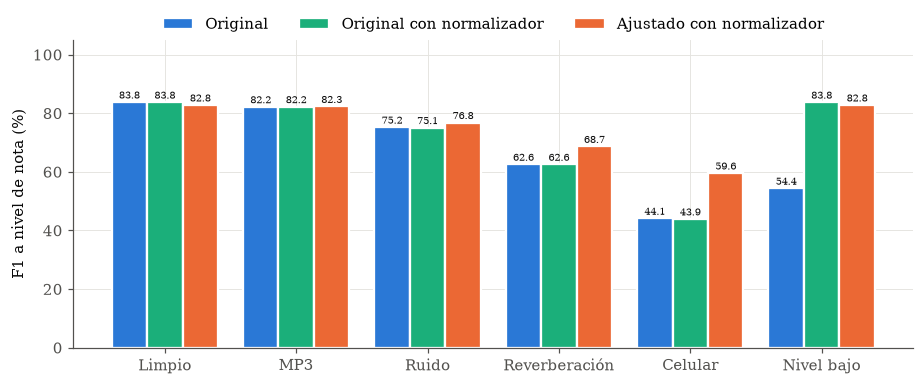

In [3]:
a = pd.read_csv(R / "oe2_ajuste_por_obra.csv")
condiciones = ["limpio", "mp3", "ruido", "reverb", "celular", "bajo"]
etiquetas = ["Limpio", "MP3", "Ruido", "Reverberación", "Celular", "Nivel bajo"]
p = a.pivot_table(index="condition", columns="variant", values="f1_note", aggfunc="mean").reindex(condiciones) * 100

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ancho = 0.27
xs = range(len(condiciones))
variantes = [("original", AZUL, "Original"), ("original_norm", AQUA, "Original con normalizador"), ("ajustado", NARANJA, "Ajustado con normalizador")]
for k, (var, color, nombre) in enumerate(variantes):
    pos = [x + (k - 1) * ancho for x in xs]
    ax.bar(pos, p[var], width=ancho, color=color, edgecolor="white", linewidth=1.5, label=nombre)
    for x, v in zip(pos, p[var]):
        ax.text(x, v + 1.2, f"{v:.1f}", ha="center", fontsize=6.5, color=TINTA)
ax.set_xticks(list(xs), etiquetas)
ax.set_ylabel("F1 a nivel de nota (%)")
ax.set_ylim(0, 105)
ax.legend(loc="upper center", ncols=3, bbox_to_anchor=(0.5, 1.12))
guardar(fig, "oe2_ajuste_por_condicion")
p.round(2)

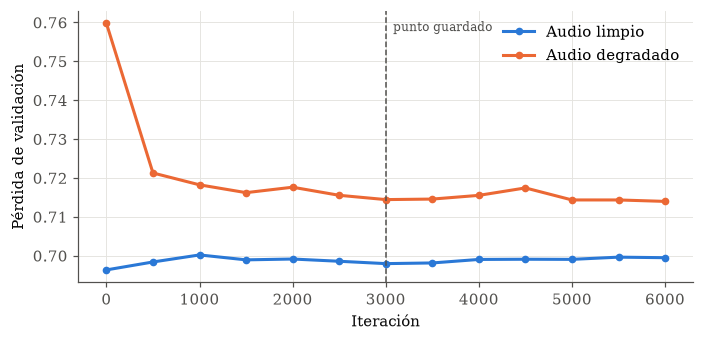

In [4]:
h = pd.DataFrame(json.loads((R / "oe2_ajuste_validacion.json").read_text()))
mejor = 3000
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(h["iteration"], h["limpio"], color=AZUL, linewidth=2, marker="o", markersize=4, label="Audio limpio")
ax.plot(h["iteration"], h["degradado"], color=NARANJA, linewidth=2, marker="o", markersize=4, label="Audio degradado")
ax.axvline(mejor, color=TINTA_2, linestyle="--", linewidth=1)
ax.text(mejor + 80, h["degradado"].max() - 0.002, "punto guardado", fontsize=8, color=TINTA_2)
ax.set_xlabel("Iteración")
ax.set_ylabel("Pérdida de validación")
ax.legend(loc="upper right")
guardar(fig, "oe2_curva_validacion")

## Cuarto objetivo: latencia

total_s            ratio        
                      mean      max    mean     max
duracion_objetivo                                  
30                  2.1417   2.1818  0.0714  0.0727
60                  4.7369   4.8536  0.0789  0.0809
120                 9.7832   9.9204  0.0815  0.0827
180                14.8307  14.9506  0.0824  0.0831
300                25.0751  25.3128  0.0836  0.0844

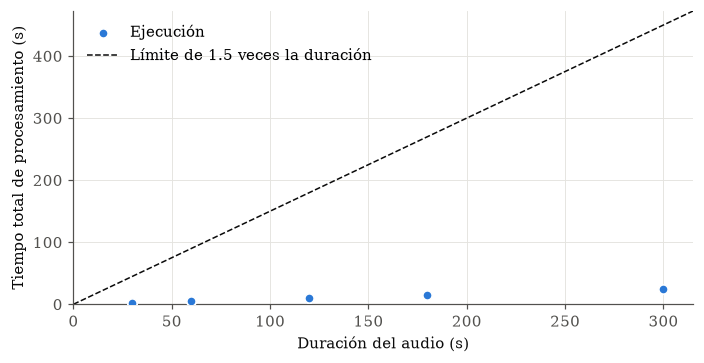

In [5]:
l = pd.read_csv(R / "oe4_latencia_e2e.csv")
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.scatter(l["audio_duration_s"], l["total_s"], s=36, color=AZUL, edgecolor="white", linewidth=1, label="Ejecución", zorder=3)
xmax = l["audio_duration_s"].max() * 1.05
ax.plot([0, xmax], [0, 1.5 * xmax], color=TINTA, linestyle="--", linewidth=1, label="Límite de 1.5 veces la duración")
ax.set_xlim(0, xmax)
ax.set_ylim(0, 1.5 * xmax)
ax.set_xlabel("Duración del audio (s)")
ax.set_ylabel("Tiempo total de procesamiento (s)")
ax.legend(loc="upper left")
guardar(fig, "oe4_latencia")
l.groupby("duracion_objetivo")[["total_s", "ratio"]].agg(["mean", "max"]).round(4)

## Quinto objetivo: Exactitud de Símbolo Braille

,legato,0.0,0.5
pieza,nombre,,
0,Aria,25.44,25.82
1,Variación 1,20.93,31.82
2,Variación 2,21.12,26.87
3,Variación 3,22.70,28.22
4,Variación 4,25.69,29.75
5,Variación 5,17.43,20.22
6,Variación 6,26.44,28.14
7,Variación 7,26.44,27.59
8,Variación 8,23.82,26.76


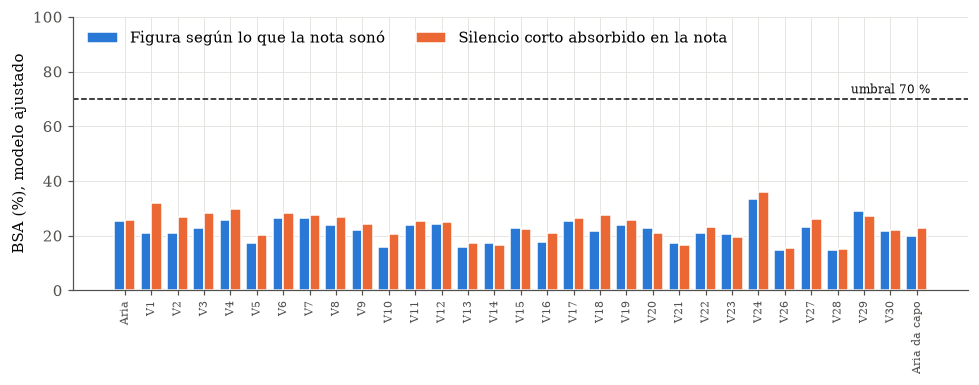

In [6]:
archivo = R / "oe5_bsa_por_pieza.csv"
if archivo.exists():
    e = pd.read_csv(archivo)
    e = e[e["modelo"] == "ajustado"]
    t = e.pivot_table(index=["pieza", "nombre"], columns="legato", values="bsa").mul(100).sort_index()
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ancho = 0.4
    xs = range(len(t))
    for k, (var, color, nombre) in enumerate([(0.0, AZUL, "Figura según lo que la nota sonó"), (0.5, NARANJA, "Silencio corto absorbido en la nota")]):
        ax.bar([x + (k - 0.5) * ancho for x in xs], t[var], width=ancho, color=color, edgecolor="white", linewidth=1, label=nombre)
    ax.axhline(70, color=TINTA, linestyle="--", linewidth=1)
    ax.text(len(t) - 0.5, 72, "umbral 70 %", ha="right", fontsize=8, color=TINTA)
    ax.set_xticks(list(xs), [n.replace("Variación ", "V") for _, n in t.index], rotation=90, fontsize=7.5)
    ax.set_ylabel("BSA (%), modelo ajustado")
    ax.set_ylim(0, 100)
    ax.legend(loc="upper left", ncols=2)
    guardar(fig, "oe5_bsa_por_pieza")
    display(t.round(2))